# 10장 실습 — SNN으로 회귀 문제 풀기

**Spiking Neural Networks 쿡북 with Python** · 10장 실습 노트북

출력 뉴런의 **막전위를 연속 출력값**으로 읽어, 목표 곡선을 따라가도록 SNN을 학습시킨다. 마지막에 순환 LIF(RLeaky)도 살펴본다.

### 학습 목표
- 출력층 LIF의 리셋을 꺼 막전위로 연속값을 표현한다.
- MSE 손실과 BPTT로 막전위가 목표 곡선을 따라가게 학습한다.
- `snn.RLeaky`(순환 LIF)의 동작을 확인한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. 목표 곡선과 입력 만들기

시간에 따라 변하는 **제곱근 곡선**을 목표로 삼는다. 입력은 0→1로 증가하는 단순한 신호다. 형태는 (시간, 배치, 특징) = (T, 1, 1)이다.

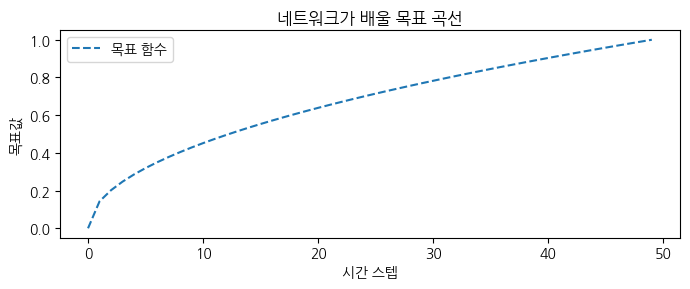

In [2]:
num_steps = 50

t = torch.linspace(0, 1, num_steps)
feature = t.view(num_steps, 1, 1)                 # 입력: 0→1 증가
target = torch.sqrt(t).view(num_steps, 1, 1)      # 목표: 제곱근 곡선

plt.figure(figsize=(7, 3))
plt.plot(target[:, 0, 0], '--', label='목표 함수')
plt.xlabel('시간 스텝'); plt.ylabel('목표값'); plt.title('네트워크가 배울 목표 곡선')
plt.legend(); plt.tight_layout(); plt.show()

## 3. 회귀용 SNN 정의

은닉층은 일반 LIF, **출력층은 리셋을 끈 LIF**(`reset_mechanism='none'`)다. 출력 뉴런은 발화 대신 막전위를 연속 출력으로 내보낸다. `forward`는 시간 스텝마다 막전위를 모아 (T, 배치, 1)로 반환한다.

In [3]:
class RegNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()
        self.fc_in = nn.Linear(1, hidden)
        self.lif_in = snn.Leaky(beta=0.9, learn_beta=True, spike_grad=spike_grad)
        self.fc_out = nn.Linear(hidden, 1)
        # 출력 뉴런: 리셋을 꺼 막전위가 연속값을 자유롭게 표현
        self.li_out = snn.Leaky(beta=0.9, learn_beta=True, spike_grad=spike_grad,
                                reset_mechanism='none')

    def forward(self, x):
        mem_in = self.lif_in.init_leaky()
        mem_out = self.li_out.init_leaky()
        mem_out_rec = []
        for step in range(x.size(0)):
            cur_in = self.fc_in(x[step])
            spk_in, mem_in = self.lif_in(cur_in, mem_in)
            cur_out = self.fc_out(spk_in)
            spk_out, mem_out = self.li_out(cur_out, mem_out)
            mem_out_rec.append(mem_out)
        return torch.stack(mem_out_rec)            # (T, 배치, 1)

model = RegNet()
print(model)

RegNet(
  (fc_in): Linear(in_features=1, out_features=128, bias=True)
  (lif_in): Leaky()
  (fc_out): Linear(in_features=128, out_features=1, bias=True)
  (li_out): Leaky()
)


## 4. 학습 전 출력 확인

학습 전에는 출력 막전위가 목표와 무관하다.

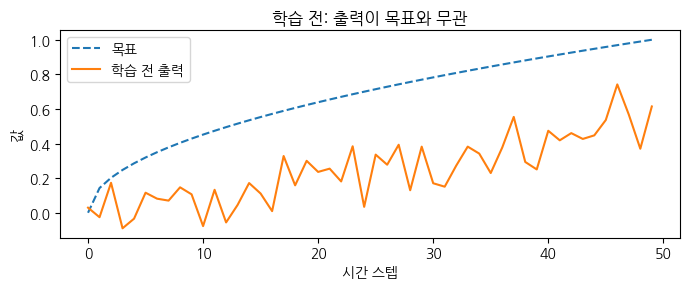

In [4]:
with torch.no_grad():
    pred = model(feature)

plt.figure(figsize=(7, 3))
plt.plot(target[:, 0, 0], '--', label='목표')
plt.plot(pred[:, 0, 0], label='학습 전 출력')
plt.xlabel('시간 스텝'); plt.ylabel('값'); plt.title('학습 전: 출력이 목표와 무관')
plt.legend(); plt.tight_layout(); plt.show()

## 5. 학습 (MSE + BPTT)

출력 막전위와 목표의 평균제곱오차를 줄인다. `backward()`가 시간 전개 그래프에 BPTT를 수행한다.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loss_hist = []

for iteration in range(300):
    pred = model(feature)              # 시간 전개 순전파
    loss_val = loss_fn(pred, target)   # 막전위 vs 목표 MSE
    optimizer.zero_grad()
    loss_val.backward()                # BPTT
    optimizer.step()
    loss_hist.append(loss_val.item())

print(f'최종 손실: {loss_hist[-1]:.5f}')

최종 손실: 0.00346


## 6. 학습 후 결과

출력 막전위가 목표 곡선을 따라간다.

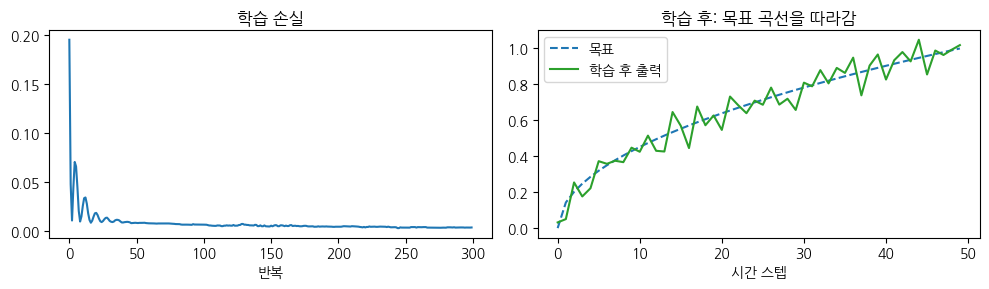

In [6]:
with torch.no_grad():
    pred = model(feature)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3))
a0.plot(loss_hist, color='tab:blue'); a0.set_title('학습 손실'); a0.set_xlabel('반복')
a1.plot(target[:, 0, 0], '--', label='목표')
a1.plot(pred[:, 0, 0], color='tab:green', label='학습 후 출력')
a1.set_title('학습 후: 목표 곡선을 따라감'); a1.set_xlabel('시간 스텝'); a1.legend()
plt.tight_layout(); plt.show()

## 7. 순환 LIF (RLeaky) 맛보기

`snn.RLeaky`는 자신의 과거 스파이크를 되먹이는 순환 뉴런이다. 임의 입력에 대한 막전위 반응을 본다.

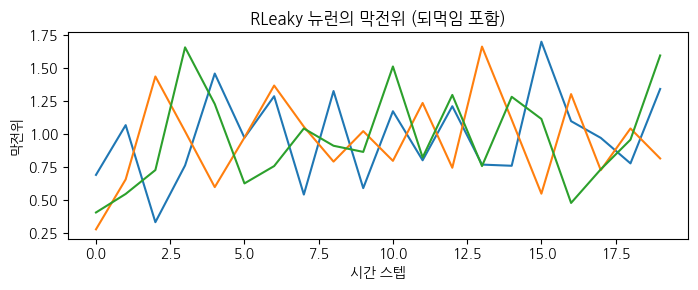

In [7]:
rlif = snn.RLeaky(beta=0.9, linear_features=10)   # 순환 LIF (10개 뉴런)
spk, mem = rlif.init_rleaky()
x = torch.rand(10)
mem_rec = []
for step in range(20):
    spk, mem = rlif(x, spk, mem)      # 입력 + 자기 스파이크 되먹임
    mem_rec.append(mem)
mem_rec = torch.stack(mem_rec).detach()

plt.figure(figsize=(7, 3))
plt.plot(mem_rec[:, :3])             # 뉴런 3개의 막전위
plt.xlabel('시간 스텝'); plt.ylabel('막전위'); plt.title('RLeaky 뉴런의 막전위 (되먹임 포함)')
plt.tight_layout(); plt.show()

## 정리

- 출력층 LIF의 리셋을 꺼 막전위로 연속값을 표현했다.
- 막전위와 목표의 MSE를 BPTT로 줄여 곡선을 학습했다.
- `snn.RLeaky`는 되먹임으로 더 긴 시간 의존성을 다룬다.

다음 11장에서는 출력으로 입력을 재구성하는 스파이킹 오토인코더를 만든다.